In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
from tqdm.auto import tqdm

import random
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input, Concatenate
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam


In [2]:
# ============================================================
# Recursive LSTM Forecasting of Schmidt Stability
# 7-day history window, 1-day forecast horizon, 3-hour issuance
# Retrospective operational-style rolling-origin forecasting
# Reduced weather predictors + stronger regularization
# ============================================================

import warnings
from pathlib import Path

warnings.filterwarnings("ignore")

from tqdm.auto import tqdm

import random
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input, Concatenate
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam


# ============================================================
# 0. BASIC SETTINGS
# ============================================================

mpl.rcParams["font.family"] = "Times New Roman"
mpl.rcParams["font.size"] = 16

SEED = 42
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)


# ============================================================
# 1. FILES AND MODEL SETTINGS
# ============================================================

DATA_DIR = Path(r"C:/Users/sh1345/code/myproject/Project 1/data/weather data")

OBS_FILE = Path("gap filled data.xlsx")
AIRPORT_FILE = DATA_DIR / "airport_weather_3hourly_2007_to_2023.csv"
OPENMETEO_FILE = DATA_DIR / "openmeteo_bias_corrected_3hourly_forecast_period_2023_onward.csv"

OUTPUT_DIR = Path("recursive_lstm_outputs/history56_horizon8_all_weather")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

USE_LOG_TARGET = False

FORECAST_STEP_HOURS = 3
EXPECTED_FREQ = pd.Timedelta(hours=FORECAST_STEP_HOURS)

HISTORY_STEPS = 56          # previous 7 days (56 × 3 hours)
FORECAST_HORIZON_STEPS = 8  # next 24 hours (8 × 3 hours)
ISSUE_FREQUENCY_STEPS = 1   # issue a new forecast every 3 hours

train_start = None
train_end = pd.Timestamp("2018-11-30 23:59:59")

val_start = pd.Timestamp("2018-12-01 00:00:00")
val_end = pd.Timestamp("2023-02-28 23:59:59")

forecast_start = pd.Timestamp("2023-03-01 00:00:00")
forecast_end = None

LSTM_UNITS_1 = 32
LSTM_UNITS_2 = 16
DROPOUT_RATE = 0.30
DENSE_UNITS = 8
LEARNING_RATE = 5e-4

BATCH_SIZE = 32
EPOCHS = 100
EARLY_STOP_PATIENCE = 8
LR_PATIENCE = 4


# ============================================================
# 2. WEATHER COLUMN SETTINGS
# ============================================================

WEATHER_COLS = [
    "air_temperature_deg_c",
    "relative_humidity_percent",
    "wind_speed_m_s",
    "radiation_w_m2",
    "station_level_pressure_hpa",
    "wind_direction_sin",
    "wind_direction_cos",
    "gust_speed_m_s",
    "rainfall_mm"
]


# ============================================================
# 3. HELPER FUNCTIONS
# ============================================================

def evaluate_regression(y_true, y_pred, label="Set", verbose=True):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    mask = np.isfinite(y_true) & np.isfinite(y_pred)
    y_true = y_true[mask]
    y_pred = y_pred[mask]

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred) if len(y_true) > 1 else np.nan
    bias = np.mean(y_pred - y_true)
    pbias = (
        100 * np.sum(y_pred - y_true) / np.sum(y_true)
        if not np.isclose(np.sum(y_true), 0)
        else np.nan
    )

    if verbose:
        print(f"\n{label}")
        print("-" * 40)
        print(f"n     : {len(y_true)}")
        print(f"RMSE  : {rmse:.4f}")
        print(f"MAE   : {mae:.4f}")
        print(f"R2    : {r2:.4f}")
        print(f"BIAS  : {bias:.4f}")
        print(f"PBIAS : {pbias:.4f}%")

    return {
        "n": len(y_true),
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2,
        "BIAS": bias,
        "PBIAS": pbias,
    }


def add_datetime_features(df, dt_col="datetime"):
    df = df.copy()

    hour = df[dt_col].dt.hour
    doy = df[dt_col].dt.dayofyear

    df["hour_sin"] = np.sin(2 * np.pi * hour / 24)
    df["hour_cos"] = np.cos(2 * np.pi * hour / 24)
    df["doy_sin"] = np.sin(2 * np.pi * doy / 365.25)
    df["doy_cos"] = np.cos(2 * np.pi * doy / 365.25)

    return df


def inverse_s(s_scaled, scaler, s_col_idx, use_log_target=False):
    s_scaled = np.asarray(s_scaled, dtype=float)
    s_unscaled = s_scaled * scaler.scale_[s_col_idx] + scaler.mean_[s_col_idx]

    if use_log_target:
        s_unscaled = np.expm1(s_unscaled)

    return s_unscaled


def add_error_columns(df):
    df = df.copy()

    df["error"] = df["y_pred"] - df["y_true"]
    df["abs_error"] = df["error"].abs()
    df["squared_error"] = df["error"] ** 2

    return df


def summarize_by_lead(results_df, label):
    rows = []

    for lead_step, g in results_df.groupby("lead_step"):
        m = evaluate_regression(
            g["y_true"].values,
            g["y_pred"].values,
            label=f"{label}, lead {lead_step}",
            verbose=True
        )

        m["set"] = label
        m["lead_step"] = lead_step
        m["lead_hours"] = lead_step * FORECAST_STEP_HOURS

        rows.append(m)

    return pd.DataFrame(rows)


def collapse_to_latest_forecast(results_df):
    out = results_df.sort_values(["target_datetime", "issue_datetime"]).copy()
    out = out.groupby("target_datetime", as_index=False).tail(1)
    out = out.sort_values("target_datetime").reset_index(drop=True)

    return out


# ============================================================
# 4. LOAD AND PREPARE CONTINUOUS MODELLING DATA
# ============================================================

print("Loading datasets...")

for required_file in [OBS_FILE, AIRPORT_FILE, OPENMETEO_FILE]:
    if not required_file.exists():
        raise FileNotFoundError(
            f"Required input file was not found: {required_file.resolve()}"
        )

df_obs = pd.read_excel(OBS_FILE).copy()
df_obs["datetime"] = pd.to_datetime(df_obs["datetime"], errors="coerce")
df_obs = (
    df_obs.dropna(subset=["datetime"])
    .sort_values("datetime")
    .drop_duplicates("datetime", keep="last")
    .reset_index(drop=True)
)

if "S" not in df_obs.columns:
    raise ValueError("The stability file must contain an 'S' column.")

airport = pd.read_csv(AIRPORT_FILE).copy()
airport = airport.rename(columns={"datetime_NZ": "datetime"})
airport["datetime"] = pd.to_datetime(airport["datetime"], errors="coerce")

openmeteo = pd.read_csv(OPENMETEO_FILE).copy()
openmeteo = openmeteo.rename(columns={"datetime_NZ": "datetime"})
openmeteo["datetime"] = pd.to_datetime(openmeteo["datetime"], errors="coerce")

for name, weather_df in [("Airport", airport), ("Open-Meteo", openmeteo)]:
    missing_cols = [c for c in ["datetime"] + WEATHER_COLS if c not in weather_df.columns]
    if missing_cols:
        raise ValueError(f"{name} file is missing columns: {missing_cols}")

airport = (
    airport[["datetime"] + WEATHER_COLS]
    .dropna(subset=["datetime"])
    .sort_values("datetime")
    .drop_duplicates("datetime", keep="last")
    .reset_index(drop=True)
)

openmeteo = (
    openmeteo[["datetime"] + WEATHER_COLS]
    .dropna(subset=["datetime"])
    .sort_values("datetime")
    .drop_duplicates("datetime", keep="last")
    .reset_index(drop=True)
)

airport_period = airport[airport["datetime"] < forecast_start].copy()
airport_period["weather_source"] = "Airport"

openmeteo_period = openmeteo[openmeteo["datetime"] >= forecast_start].copy()
openmeteo_period["weather_source"] = "OpenMeteo_bias_corrected"

weather = (
    pd.concat([airport_period, openmeteo_period], ignore_index=True)
    .sort_values("datetime")
    .drop_duplicates("datetime", keep="last")
    .reset_index(drop=True)
)

print("\nWeather handover")
print("-" * 40)
print("Last airport timestamp:", airport_period["datetime"].max())
print("First Open-Meteo timestamp:", openmeteo_period["datetime"].min())

df = df_obs.merge(weather, on="datetime", how="inner")
df = df.sort_values("datetime").reset_index(drop=True)

if train_start is None:
    train_start = df["datetime"].min()

if forecast_end is None:
    forecast_end = df["datetime"].max()
else:
    forecast_end = min(pd.Timestamp(forecast_end), df["datetime"].max())

df = df[
    (df["datetime"] >= train_start) &
    (df["datetime"] <= forecast_end)
].copy().reset_index(drop=True)

# Confirm that the interpolated modelling data form one regular 3-hour grid.
time_diff = df["datetime"].diff().dropna()
bad_steps = time_diff[time_diff != EXPECTED_FREQ]

if len(bad_steps) > 0:
    raise ValueError(
        f"The merged modelling data are not on a complete 3-hour grid. "
        f"Found {len(bad_steps)} irregular steps."
    )

df["S_model"] = np.log1p(df["S"]) if USE_LOG_TARGET else df["S"]
df = add_datetime_features(df, dt_col="datetime")

time_feature_cols = [
    "hour_sin",
    "hour_cos",
    "doy_sin",
    "doy_cos",
]

history_feature_cols = (
    ["S_model"] +
    WEATHER_COLS +
    time_feature_cols
)

future_feature_cols = (
    WEATHER_COLS +
    time_feature_cols
)

S_COL_IDX = history_feature_cols.index("S_model")
nonforecast_lake_cols = []

required_cols = list(dict.fromkeys(
    ["datetime", "S", "S_model"] +
    history_feature_cols +
    future_feature_cols
))

wind_cols = ["wind_direction_sin", "wind_direction_cos"]

if all(col in df.columns for col in wind_cols):
    df[wind_cols] = (
        df[wind_cols]
        .interpolate(method="linear", limit_direction="both")
    )

    magnitude = np.sqrt(
        df["wind_direction_sin"] ** 2
        + df["wind_direction_cos"] ** 2
    )

    valid = magnitude > 0

    df.loc[valid, "wind_direction_sin"] /= magnitude[valid]
    df.loc[valid, "wind_direction_cos"] /= magnitude[valid]

missing = df[required_cols].isna().sum()
if missing.any():
    raise ValueError(
        f"Missing model values found:\n{missing[missing > 0]}"
    )

model_df = df[required_cols].copy()
model_df = model_df.sort_values("datetime").reset_index(drop=True)

print("\nHistory features")
print("-" * 40)
print(history_feature_cols)

print("\nFuture features")
print("-" * 40)
print(future_feature_cols)

print("\nModelling dataframe")
print("-" * 40)
print("Rows:", len(model_df))
print("Range:", model_df["datetime"].min(), "to", model_df["datetime"].max())
print("Regular 3-hour grid: confirmed")

Loading datasets...

Weather handover
----------------------------------------
Last airport timestamp: 2023-02-28 21:00:00
First Open-Meteo timestamp: 2023-03-01 00:00:00

History features
----------------------------------------
['S_model', 'air_temperature_deg_c', 'relative_humidity_percent', 'wind_speed_m_s', 'radiation_w_m2', 'station_level_pressure_hpa', 'wind_direction_sin', 'wind_direction_cos', 'gust_speed_m_s', 'rainfall_mm', 'hour_sin', 'hour_cos', 'doy_sin', 'doy_cos']

Future features
----------------------------------------
['air_temperature_deg_c', 'relative_humidity_percent', 'wind_speed_m_s', 'radiation_w_m2', 'station_level_pressure_hpa', 'wind_direction_sin', 'wind_direction_cos', 'gust_speed_m_s', 'rainfall_mm', 'hour_sin', 'hour_cos', 'doy_sin', 'doy_cos']

Modelling dataframe
----------------------------------------
Rows: 54536
Range: 2007-07-13 12:00:00 to 2026-03-12 09:00:00
Regular 3-hour grid: confirmed


In [3]:



# ============================================================
# 10. SPLIT DATA
# ============================================================

train_mask = (model_df["datetime"] >= train_start) & (model_df["datetime"] <= train_end)
val_mask = (model_df["datetime"] >= val_start) & (model_df["datetime"] <= val_end)
forecast_mask = model_df["datetime"] >= forecast_start

if forecast_end is not None:
    forecast_mask = forecast_mask & (model_df["datetime"] <= forecast_end)

train_df = model_df.loc[train_mask].copy()
val_df = model_df.loc[val_mask].copy()
forecast_df = model_df.loc[forecast_mask].copy()

if len(train_df) == 0:
    raise ValueError("Training period is empty.")

if len(val_df) == 0:
    raise ValueError("Validation period is empty.")

if len(forecast_df) == 0:
    raise ValueError("Forecast period is empty.")

print("\nData splits")
print("-" * 40)
print("Train     :", train_start, "to", train_end, "| rows:", len(train_df))
print("Validation:", val_start, "to", val_end, "| rows:", len(val_df))
print("Forecast  :", forecast_start, "to", forecast_end if forecast_end else "end of data", "| rows:", len(forecast_df))


# ============================================================
# 10A. TARGET DISTRIBUTION CHECK
# ============================================================

def describe_target(df_part, name):
    print(f"\n{name} S distribution")
    print("-" * 40)
    print(df_part["S"].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]))

describe_target(train_df, "Training")
describe_target(val_df, "Validation")
describe_target(forecast_df, "Forecast")


# ============================================================
# 11. SCALE FEATURES USING TRAINING PERIOD ONLY
# ============================================================

history_scaler = StandardScaler()
future_scaler = StandardScaler()

history_scaler.fit(train_df[history_feature_cols].astype(float))
future_scaler.fit(train_df[future_feature_cols].astype(float))

model_df_scaled = model_df.copy()

model_df_scaled[history_feature_cols] = history_scaler.transform(
    model_df[history_feature_cols].astype(float)
)

model_df_scaled[future_feature_cols] = future_scaler.transform(
    model_df[future_feature_cols].astype(float)
)


# ============================================================
# 12. BUILD ONE-STEP TRAINING SEQUENCES
# ============================================================

def build_one_step_sequences(
    full_df_scaled,
    history_feature_cols,
    future_feature_cols,
    target_col,
    start_dt,
    end_dt,
    history_steps,
    issue_stride=1
):
    """Build samples directly across the complete regular 3-hour grid."""
    X_hist, X_future, y, meta = [], [], [], []

    data = full_df_scaled.sort_values("datetime").reset_index(drop=True)

    for j in range(history_steps, len(data), issue_stride):
        target_dt = data.loc[j, "datetime"]
        issue_dt = data.loc[j - 1, "datetime"]

        if target_dt < start_dt:
            continue
        if end_dt is not None and target_dt > end_dt:
            continue

        hist_window = data.loc[
            j - history_steps:j - 1,
            history_feature_cols
        ]
        future_row = data.loc[j, future_feature_cols]
        target_value = data.loc[j, target_col]

        X_hist.append(hist_window.to_numpy(dtype=np.float32))
        X_future.append(future_row.to_numpy(dtype=np.float32))
        y.append(float(target_value))

        meta.append({
            "issue_datetime": issue_dt,
            "target_datetime": target_dt,
        })

    return (
        np.asarray(X_hist, dtype=np.float32),
        np.asarray(X_future, dtype=np.float32),
        np.asarray(y, dtype=np.float32),
        pd.DataFrame(meta)
    )


X_train_hist, X_train_future, y_train, train_meta = build_one_step_sequences(
    model_df_scaled,
    history_feature_cols,
    future_feature_cols,
    target_col="S_model",
    start_dt=train_start,
    end_dt=train_end,
    history_steps=HISTORY_STEPS,
    issue_stride=1
)

X_val_hist, X_val_future, y_val, val_meta = build_one_step_sequences(
    model_df_scaled,
    history_feature_cols,
    future_feature_cols,
    target_col="S_model",
    start_dt=val_start,
    end_dt=val_end,
    history_steps=HISTORY_STEPS,
    issue_stride=1
)

X_forecast_hist, X_forecast_future, y_forecast, forecast_one_step_meta = build_one_step_sequences(
    model_df_scaled,
    history_feature_cols,
    future_feature_cols,
    target_col="S_model",
    start_dt=forecast_start,
    end_dt=forecast_end,
    history_steps=HISTORY_STEPS,
    issue_stride=1
)

print("\nOne-step sequence shapes")
print("-" * 40)
print("X_train_hist      :", X_train_hist.shape)
print("X_train_future    :", X_train_future.shape)
print("y_train           :", y_train.shape)
print("X_val_hist        :", X_val_hist.shape)
print("X_val_future      :", X_val_future.shape)
print("y_val             :", y_val.shape)
print("X_forecast_hist   :", X_forecast_hist.shape)
print("X_forecast_future :", X_forecast_future.shape)
print("y_forecast        :", y_forecast.shape)

if len(X_train_hist) == 0:
    raise ValueError("No training sequences created.")
if len(X_val_hist) == 0:
    raise ValueError("No validation sequences created.")
if len(X_forecast_hist) == 0:
    raise ValueError("No forecast one-step sequences created.")



Data splits
----------------------------------------
Train     : 2007-07-13 12:00:00 to 2018-11-30 23:59:59 | rows: 33268
Validation: 2018-12-01 00:00:00 to 2023-02-28 23:59:59 | rows: 12408
Forecast  : 2023-03-01 00:00:00 to 2026-03-12 09:00:00 | rows: 8860

Training S distribution
----------------------------------------
count    33268.000000
mean        28.776391
std         40.320878
min          0.000000
1%           0.000000
5%           0.000000
25%          1.009890
50%          8.857660
75%         45.408835
95%        110.996245
99%        172.670531
max        314.995208
Name: S, dtype: float64

Validation S distribution
----------------------------------------
count    12408.000000
mean        27.713569
std         36.004501
min          0.000000
1%           0.000000
5%           0.000000
25%          1.433105
50%         11.429210
75%         40.698971
95%        113.856553
99%        134.911784
max        179.690135
Name: S, dtype: float64

Forecast S distribution
-----

In [4]:
# ============================================================
# 13. BUILD KERAS ONE-STEP LSTM MODEL
# ============================================================

def build_model(history_shape, future_shape):
    history_input = Input(shape=history_shape, name="history_input")

    x = LSTM(LSTM_UNITS_1, return_sequences=True)(history_input)
    x = Dropout(DROPOUT_RATE)(x)

    x = LSTM(LSTM_UNITS_2, return_sequences=False)(x)
    x = Dropout(DROPOUT_RATE)(x)

    future_input = Input(shape=future_shape, name="future_input")

    z = Dense(DENSE_UNITS, activation="relu")(future_input)
    z = Dropout(DROPOUT_RATE)(z)

    combined = Concatenate()([x, z])
    combined = Dense(DENSE_UNITS, activation="relu")(combined)
    combined = Dropout(DROPOUT_RATE)(combined)

    output = Dense(1, activation="linear", name="S_pred_one_step")(combined)

    model = Model(inputs=[history_input, future_input], outputs=output)

    model.compile(
        optimizer=Adam(learning_rate=LEARNING_RATE),
        loss="mse",
        metrics=["mae"]
    )

    return model


model = build_model(
    history_shape=(X_train_hist.shape[1], X_train_hist.shape[2]),
    future_shape=(X_train_future.shape[1],)
)

model.summary()


# ============================================================
# 14. TRAIN MODEL
# ============================================================

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=EARLY_STOP_PATIENCE,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=LR_PATIENCE,
    min_lr=1e-6,
    verbose=1
)

history = model.fit(
    [X_train_hist, X_train_future],
    y_train,
    validation_data=([X_val_hist, X_val_future], y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)




Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ history_input       │ (None, 56, 14)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 56, 32)    │      6,016 │ history_input[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 56, 32)    │          0 │ lstm[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ future_input        │ (None, 13)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ (None, 16)        │      3,136 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 8)         │        112 │ future_input[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 16)        │          0 │ lstm_1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 8)         │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 24)        │          0 │ dropout_1[0][0],  │
│ (Concatenate)       │                   │            │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 8)         │        200 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 8)         │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ S_pred_one_step     │ (None, 1)         │          9 │ dropout_3[0][0]   │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 9,473 (37.00 KB)

 Trainable params: 9,473 (37.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
1038/1038 ━━━━━━━━━━━━━━━━━━━━ 18s 16ms/step - loss: 0.3257 - mae: 0.3877 - val_loss: 0.1345 - val_mae: 0.2511 - learning_rate: 5.0000e-04
Epoch 2/100
1038/1038 ━━━━━━━━━━━━━━━━━━━━ 15s 15ms/step - loss: 0.1963 - mae: 0.2941 - val_loss: 0.1142 - val_mae: 0.2278 - learning_rate: 5.0000e-04
Epoch 3/100
1038/1038 ━━━━━━━━━━━━━━━━━━━━ 16s 15ms/step - loss: 0.1789 - mae: 0.2767 - val_loss: 0.1037 - val_mae: 0.2082 - learning_rate: 5.0000e-04
Epoch 4/100
1038/1038 ━━━━━━━━━━━━━━━━━━━━ 16s 15ms/step - loss: 0.1653 - mae: 0.2658 - val_loss: 0.0920 - val_mae: 0.2012 - learning_rate: 5.0000e-04
Epoch 5/100
1038/1038 ━━━━━━━━━━━━━━━━━━━━ 16s 15ms/step - loss: 0.1588 - mae: 0.2601 - val_loss: 0.0758 - val_mae: 0.1757 - learning_rate: 5.0000e-04
Epoch 6/100
1038/1038 ━━━━━━━━━━━━━━━━━━━━ 16s 15ms/step - loss: 0.1528 - mae: 0.2547 - val_loss: 0.0742 - val_mae: 0.1733 - learning_rate: 5.0000e-04
Epoch 7/100
1038/1038 ━━━━━━━━━━━━━━━━━━━━ 16s 15ms/step - loss: 0.1576 - mae: 0.2570 - val_lo

In [5]:
# ============================================================
# 15. ONE-STEP VALIDATION AND FORECAST CHECKS
# ============================================================

val_pred_scaled = model.predict([X_val_hist, X_val_future], verbose=0).reshape(-1)

val_true = inverse_s(y_val, history_scaler, S_COL_IDX, USE_LOG_TARGET)
val_pred = inverse_s(val_pred_scaled, history_scaler, S_COL_IDX, USE_LOG_TARGET)

one_step_val_metrics = evaluate_regression(
    val_true,
    val_pred,
    label="One-step validation performance"
)

forecast_one_step_pred_scaled = model.predict(
    [X_forecast_hist, X_forecast_future],
    verbose=0
).reshape(-1)

forecast_one_step_true = inverse_s(
    y_forecast,
    history_scaler,
    S_COL_IDX,
    USE_LOG_TARGET
)

forecast_one_step_pred = inverse_s(
    forecast_one_step_pred_scaled,
    history_scaler,
    S_COL_IDX,
    USE_LOG_TARGET
)

forecast_one_step_metrics = evaluate_regression(
    forecast_one_step_true,
    forecast_one_step_pred,
    label="One-step forecast-period performance"
)

print("\nOne-step forecast-period diagnostic")
print("-" * 40)
print("Mean observed S :", np.mean(forecast_one_step_true))
print("Mean predicted S:", np.mean(forecast_one_step_pred))
print("Mean error      :", np.mean(forecast_one_step_pred - forecast_one_step_true))


# ============================================================
# 16. RECURSIVE FORECASTING FUNCTION
# ============================================================

def make_recursive_forecasts(
    full_df_raw,
    full_df_scaled,
    issue_start,
    issue_end=None,
    label="forecast_recursive",
    issue_stride=1
):
    """Create recursive forecasts across one continuous regular 3-hour grid."""
    rows = []

    data_raw = full_df_raw.sort_values("datetime").reset_index(drop=True)
    data_scaled = full_df_scaled.sort_values("datetime").reset_index(drop=True)
    n = len(data_raw)

    if n < HISTORY_STEPS + FORECAST_HORIZON_STEPS:
        return pd.DataFrame()

    latest_possible_issue = data_raw["datetime"].max() - pd.Timedelta(
        hours=FORECAST_HORIZON_STEPS * FORECAST_STEP_HOURS
    )
    max_issue_dt = (
        latest_possible_issue
        if issue_end is None
        else min(pd.Timestamp(issue_end), latest_possible_issue)
    )

    valid_issue_indices = [
        j
        for j in range(
            HISTORY_STEPS - 1,
            n - FORECAST_HORIZON_STEPS,
            issue_stride
        )
        if issue_start <= data_raw.loc[j, "datetime"] <= max_issue_dt
    ]

    print(
        f"\n{label}: {len(valid_issue_indices)} issue times, "
        f"{len(valid_issue_indices) * FORECAST_HORIZON_STEPS} "
        "recursive predictions"
    )

    for j in tqdm(valid_issue_indices, desc=label):
        issue_dt = data_raw.loc[j, "datetime"]

        current_window = data_scaled.loc[
            j - HISTORY_STEPS + 1:j,
            history_feature_cols
        ].copy().reset_index(drop=True)

        for h in range(1, FORECAST_HORIZON_STEPS + 1):
            target_idx = j + h
            target_dt = data_raw.loc[target_idx, "datetime"]
            future_row = data_scaled.loc[target_idx, future_feature_cols]

            X_hist_input = current_window.to_numpy(
                dtype=np.float32
            ).reshape(1, HISTORY_STEPS, len(history_feature_cols))

            X_future_input = future_row.to_numpy(
                dtype=np.float32
            ).reshape(1, len(future_feature_cols))

            pred_scaled = float(
                model(
                    [X_hist_input, X_future_input],
                    training=False
                ).numpy().reshape(-1)[0]
            )

            pred_unscaled = float(
                inverse_s(
                    np.array([pred_scaled]),
                    history_scaler,
                    S_COL_IDX,
                    USE_LOG_TARGET
                )[0]
            )

            rows.append({
                "set": label,
                "issue_datetime": issue_dt,
                "target_datetime": target_dt,
                "lead_step": h,
                "lead_hours": h * FORECAST_STEP_HOURS,
                "y_true": float(data_raw.loc[target_idx, "S"]),
                "y_pred": pred_unscaled,
            })

            # Feed predicted S back into history while using known
            # target-time weather and calendar features.
            new_row = pd.Series(index=history_feature_cols, dtype=float)
            new_row["S_model"] = pred_scaled
            new_row[future_feature_cols] = future_row.values

            current_window = pd.concat(
                [
                    current_window.iloc[1:].reset_index(drop=True),
                    pd.DataFrame([new_row], columns=history_feature_cols)
                ],
                ignore_index=True
            )

    out = pd.DataFrame(rows)
    return add_error_columns(out) if not out.empty else out


print("\nRecursive forecast workload estimate")
print("-" * 40)
print("History steps        :", HISTORY_STEPS)
print("History hours        :", HISTORY_STEPS * FORECAST_STEP_HOURS)
print("Forecast horizon steps:", FORECAST_HORIZON_STEPS)
print("Forecast horizon hours:", FORECAST_HORIZON_STEPS * FORECAST_STEP_HOURS)
print("Issue frequency steps :", ISSUE_FREQUENCY_STEPS)
print("Issue frequency hours :", ISSUE_FREQUENCY_STEPS * FORECAST_STEP_HOURS)



One-step validation performance
----------------------------------------
n     : 12408
RMSE  : 7.2960
MAE   : 4.8785
R2    : 0.9589
BIAS  : 0.3462
PBIAS : 1.2493%

One-step forecast-period performance
----------------------------------------
n     : 8860
RMSE  : 6.9815
MAE   : 4.7034
R2    : 0.9492
BIAS  : 1.3631
PBIAS : 7.3474%

One-step forecast-period diagnostic
----------------------------------------
Mean observed S : 18.55160284104358
Mean predicted S: 19.9146588698103
Mean error      : 1.3630560287667228

Recursive forecast workload estimate
----------------------------------------
History steps        : 56
History hours        : 168
Forecast horizon steps: 8
Forecast horizon hours: 24
Issue frequency steps : 1
Issue frequency hours : 3


In [6]:



# ============================================================
# 17. VALIDATION RECURSIVE FORECASTS
# ============================================================

# Keep validation targets inside validation period
val_issue_end = val_end - pd.Timedelta(
    hours=FORECAST_HORIZON_STEPS * FORECAST_STEP_HOURS
)

val_results = make_recursive_forecasts(
    full_df_raw=model_df,
    full_df_scaled=model_df_scaled,
    issue_start=val_start,
    issue_end=val_issue_end,
    label="validation_recursive",
    issue_stride=ISSUE_FREQUENCY_STEPS
)

if len(val_results) == 0:
    raise ValueError("No recursive validation forecasts created.")

val_metrics = evaluate_regression(
    val_results["y_true"].values,
    val_results["y_pred"].values,
    label="Validation recursive forecasts"
)


# ============================================================
# 18. FORECAST PERIOD RECURSIVE FORECASTS
# ============================================================

forecast_results = make_recursive_forecasts(
    full_df_raw=model_df,
    full_df_scaled=model_df_scaled,
    issue_start=forecast_start,
    issue_end=forecast_end,
    label="forecast_recursive",
    issue_stride=ISSUE_FREQUENCY_STEPS
)

if len(forecast_results) == 0:
    raise ValueError("No recursive forecast-period forecasts created.")

forecast_metrics = evaluate_regression(
    forecast_results["y_true"].values,
    forecast_results["y_pred"].values,
    label="Forecast-period recursive forecasts"
)


# ============================================================
# 18A. FORECAST RESULT DIAGNOSTIC
# ============================================================

print("\nForecast result diagnostic")
print("-" * 40)

for name, res in [
    ("Validation", val_results),
    ("Forecast", forecast_results)
]:
    print(f"\n{name}")
    print("Rows:", len(res))
    print("Issue times:", res["issue_datetime"].nunique())
    print("Lead steps:", sorted(res["lead_step"].unique()))
    print("Target range:", res["target_datetime"].min(), "to", res["target_datetime"].max())
    print("Mean observed S:", res["y_true"].mean())
    print("Mean predicted S:", res["y_pred"].mean())
    print("Mean error:", (res["y_pred"] - res["y_true"]).mean())


# ============================================================
# 19. PERSISTENCE BASELINE
# ============================================================

def make_persistence_forecasts(
    full_df_raw,
    issue_start,
    issue_end=None,
    label="forecast_persistence",
    issue_stride=1
):
    """Create persistence forecasts across one continuous 3-hour grid."""
    rows = []
    data = full_df_raw.sort_values("datetime").reset_index(drop=True)
    n = len(data)

    latest_possible_issue = data["datetime"].max() - pd.Timedelta(
        hours=FORECAST_HORIZON_STEPS * FORECAST_STEP_HOURS
    )
    max_issue_dt = (
        latest_possible_issue
        if issue_end is None
        else min(pd.Timestamp(issue_end), latest_possible_issue)
    )

    for j in range(
        HISTORY_STEPS - 1,
        n - FORECAST_HORIZON_STEPS,
        issue_stride
    ):
        issue_dt = data.loc[j, "datetime"]

        if not (issue_start <= issue_dt <= max_issue_dt):
            continue

        persist_value = float(data.loc[j, "S"])

        for h in range(1, FORECAST_HORIZON_STEPS + 1):
            target_idx = j + h
            rows.append({
                "set": label,
                "issue_datetime": issue_dt,
                "target_datetime": data.loc[target_idx, "datetime"],
                "lead_step": h,
                "lead_hours": h * FORECAST_STEP_HOURS,
                "y_true": float(data.loc[target_idx, "S"]),
                "y_pred": persist_value,
            })

    out = pd.DataFrame(rows)
    return add_error_columns(out) if not out.empty else out


persistence_results = make_persistence_forecasts(
    full_df_raw=model_df,
    issue_start=forecast_start,
    issue_end=forecast_end,
    label="forecast_persistence",
    issue_stride=ISSUE_FREQUENCY_STEPS
)

if persistence_results.empty:
    raise ValueError("No persistence forecasts created.")

persistence_metrics = evaluate_regression(
    persistence_results["y_true"].values,
    persistence_results["y_pred"].values,
    label="Forecast-period persistence baseline"
)


# ============================================================
# 20. LEAD-TIME METRICS
# ============================================================

val_lead_metrics = summarize_by_lead(val_results, "validation_recursive")
forecast_lead_metrics = summarize_by_lead(forecast_results, "forecast_recursive")
persistence_lead_metrics = summarize_by_lead(persistence_results, "forecast_persistence")

lead_skill = forecast_lead_metrics.merge(
    persistence_lead_metrics,
    on=["lead_step", "lead_hours"],
    suffixes=("_model", "_persistence")
)

lead_skill["RMSE_skill_over_persistence"] = (
    1 - lead_skill["RMSE_model"] / lead_skill["RMSE_persistence"]
)

lead_skill["MAE_skill_over_persistence"] = (
    1 - lead_skill["MAE_model"] / lead_skill["MAE_persistence"]
)

print("\nLead-time performance summary")





validation_recursive: 12400 issue times, 99200 recursive predictions


validation_recursive: 100%|██████████| 12400/12400 [3:32:10<00:00,  1.03s/it] 



Validation recursive forecasts
----------------------------------------
n     : 99200
RMSE  : 15.3420
MAE   : 9.8188
R2    : 0.8185
BIAS  : -0.5675
PBIAS : -2.0469%

forecast_recursive: 8852 issue times, 70816 recursive predictions


forecast_recursive: 100%|██████████| 8852/8852 [2:29:49<00:00,  1.02s/it]  



Forecast-period recursive forecasts
----------------------------------------
n     : 70816
RMSE  : 12.0772
MAE   : 8.1069
R2    : 0.8481
BIAS  : 2.2370
PBIAS : 12.0531%

Forecast result diagnostic
----------------------------------------

Validation
Rows: 99200
Issue times: 12400
Lead steps: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]
Target range: 2018-12-01 03:00:00 to 2023-02-28 21:00:00
Mean observed S: 27.72742964170306
Mean predicted S: 27.159887455731134
Mean error: -0.5675421859719268

Forecast
Rows: 70816
Issue times: 8852
Lead steps: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]
Target range: 2023-03-01 03:00:00 to 2026-03-12 09:00:00
Mean observed S: 18.55923795826546
Mean predicted S: 20.796202837697628
Mean error: 2.2369648794321666

Forecast-period persistence baseline
----------------------------------------
n     : 70816
RMSE  : 12.4774
MAE   : 6.8745

In [7]:
# ============================================================
# 21. SAVE OUTPUTS
# ============================================================

val_results.to_csv(OUTPUT_DIR / "validation_predictions_history56_horizon8_reduced_weather.csv", index=False)
forecast_results.to_csv(OUTPUT_DIR / "forecast_predictions_history56_horizon8_reduced_weather.csv", index=False)

val_lead_metrics.to_csv(OUTPUT_DIR / "validation_lead_metrics_history56_horizon8_reduced_weather.csv", index=False)
forecast_lead_metrics.to_csv(OUTPUT_DIR / "forecast_lead_metrics_history56_horizon8_reduced_weather.csv", index=False)
persistence_lead_metrics.to_csv(OUTPUT_DIR / "forecast_lead_metrics_persistence_horizon8.csv", index=False)
lead_skill.to_csv(OUTPUT_DIR / "forecast_skill_over_persistence_history56_horizon8_reduced_weather.csv", index=False)

pd.DataFrame({"history_feature": history_feature_cols}).to_csv(
    OUTPUT_DIR / "history_features_used_history56_horizon8_reduced_weather.csv",
    index=False
)

pd.DataFrame({"future_feature": future_feature_cols}).to_csv(
    OUTPUT_DIR / "future_features_used_history56_horizon8_reduced_weather.csv",
    index=False
)

metrics_summary = pd.DataFrame([
    {"set": "one_step_validation", **one_step_val_metrics},
    {"set": "one_step_forecast", **forecast_one_step_metrics},
    {"set": "validation_recursive", **val_metrics},
    {"set": "forecast_recursive", **forecast_metrics},
    {"set": "forecast_persistence", **persistence_metrics},
])

metrics_summary.to_csv(OUTPUT_DIR / "metrics_summary_history56_horizon8_reduced_weather.csv", index=False)

model.save(OUTPUT_DIR / "recursive_lstm_schmidt_stability_history56_horizon8.keras")

print("\nSaved output files.")


Saved output files.


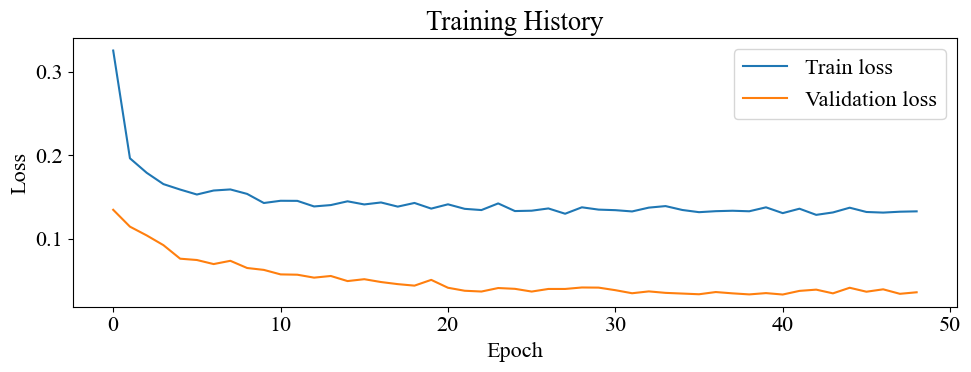

In [8]:
# ============================================================
# 22. PLOTS
# ============================================================

# Plot training history only if model was trained in this session
if "history" in globals():
    plt.figure(figsize=(10, 4))
    plt.plot(history.history["loss"], label="Train loss")
    plt.plot(history.history["val_loss"], label="Validation loss")
    plt.title("Training History")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print("Training history is not available because the model was loaded, not trained in this session.")

The duplicate forecast plot was removed. The streamlined plotting section is below.

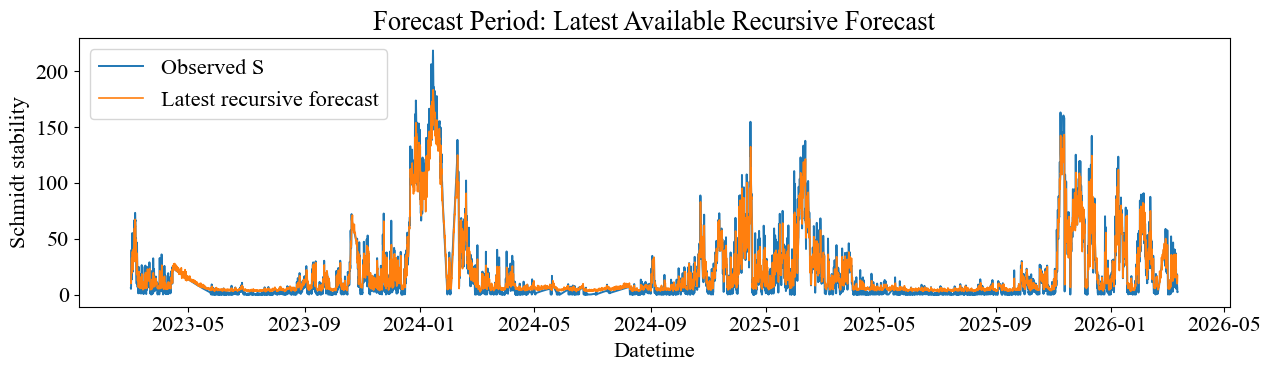

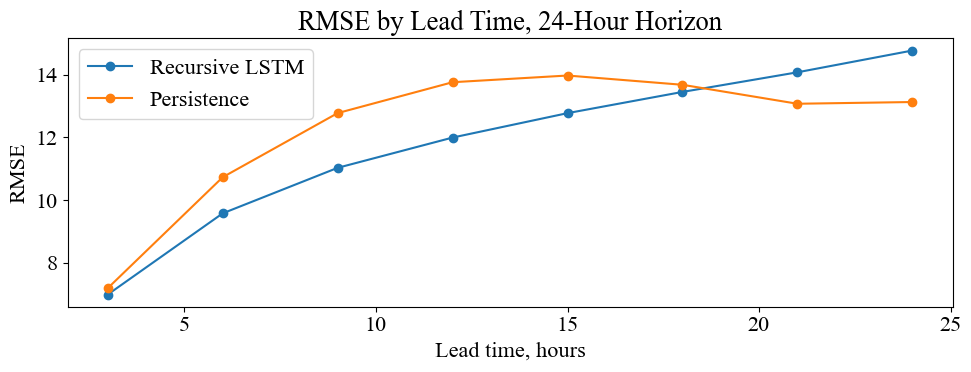

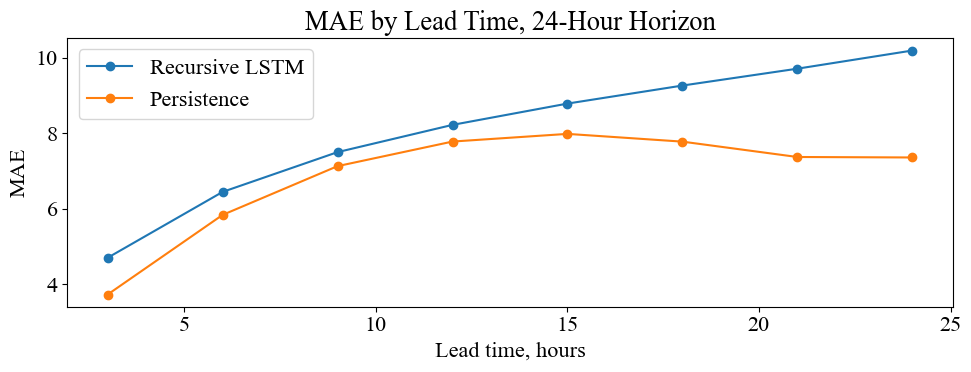

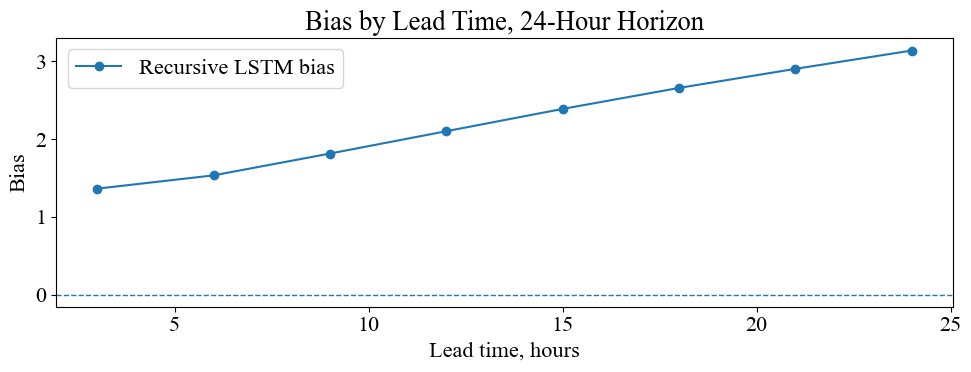

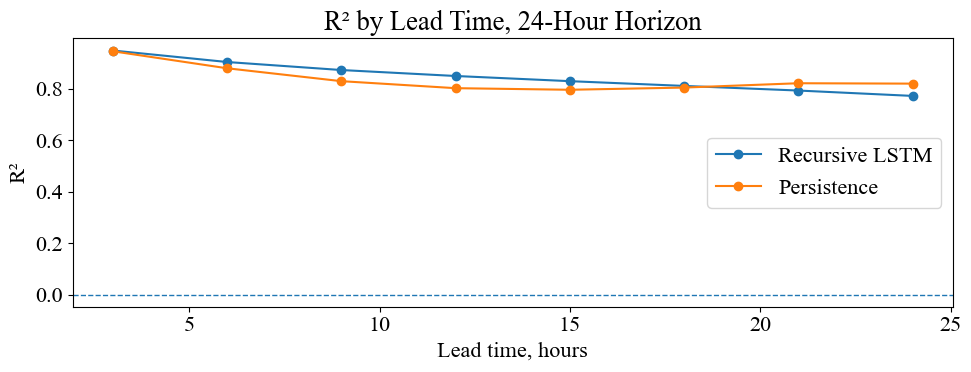

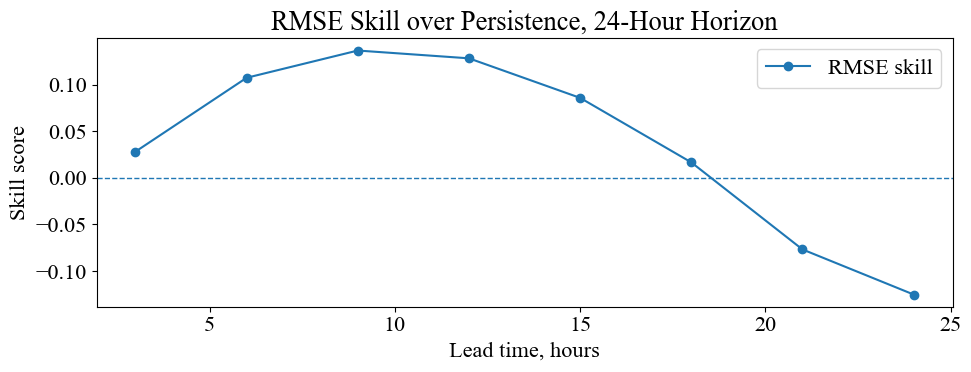

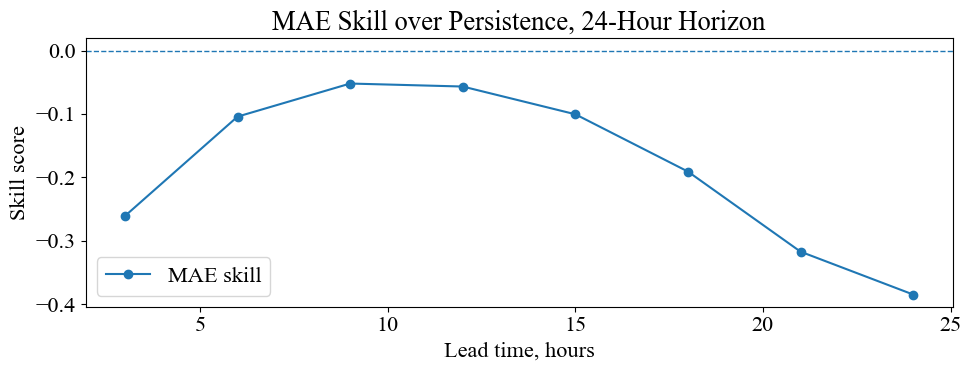

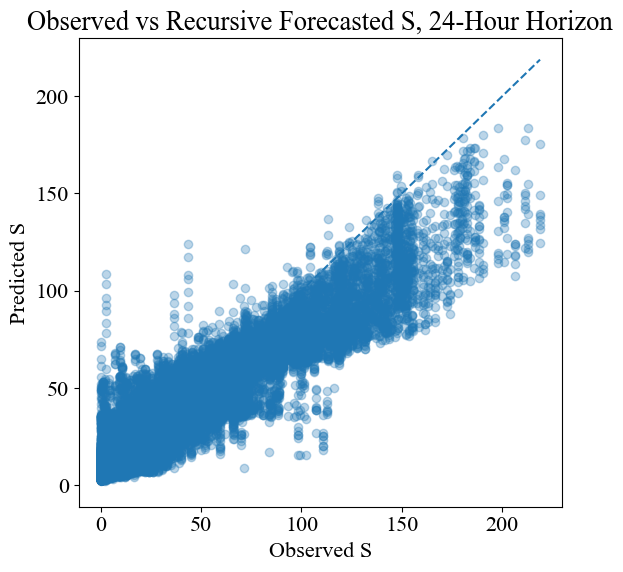

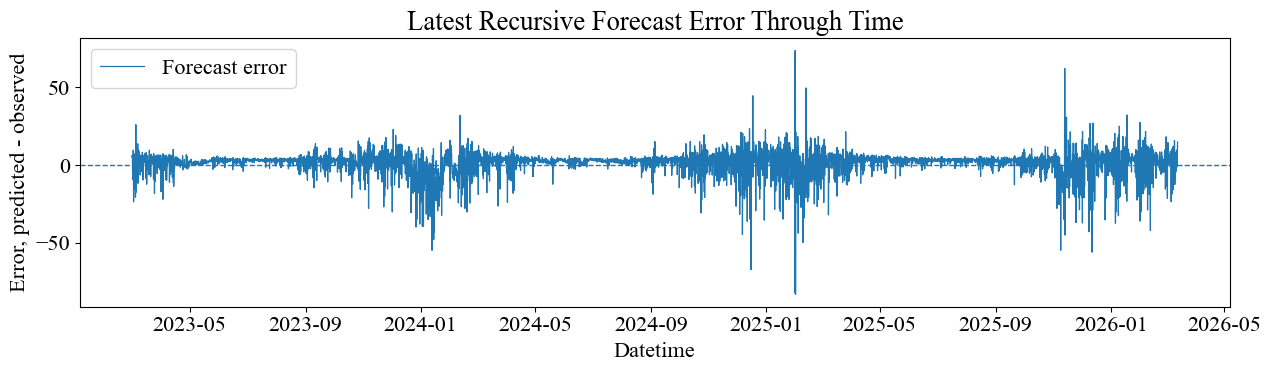


Finished plotting loaded-model results.


In [9]:
# ============================================================
# 22. PLOTS AFTER LOADING SAVED MODEL
# ============================================================

# ------------------------------------------------------------
# 1. Latest available recursive forecast vs observed
# ------------------------------------------------------------

plot_latest = collapse_to_latest_forecast(forecast_results)

plt.figure(figsize=(13, 4))
plt.plot(
    plot_latest["target_datetime"],
    plot_latest["y_true"],
    label="Observed S",
    linewidth=1.4
)
plt.plot(
    plot_latest["target_datetime"],
    plot_latest["y_pred"],
    label="Latest recursive forecast",
    linewidth=1.2
)

plt.title("Forecast Period: Latest Available Recursive Forecast")
plt.xlabel("Datetime")
plt.ylabel("Schmidt stability")
plt.legend()
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 2. RMSE by lead time: LSTM vs Persistence
# ------------------------------------------------------------

plt.figure(figsize=(10, 4))
plt.plot(
    forecast_lead_metrics["lead_hours"],
    forecast_lead_metrics["RMSE"],
    marker="o",
    label="Recursive LSTM"
)
plt.plot(
    persistence_lead_metrics["lead_hours"],
    persistence_lead_metrics["RMSE"],
    marker="o",
    label="Persistence"
)

plt.title("RMSE by Lead Time, 24-Hour Horizon")
plt.xlabel("Lead time, hours")
plt.ylabel("RMSE")
plt.legend()
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 3. MAE by lead time: LSTM vs Persistence
# ------------------------------------------------------------

plt.figure(figsize=(10, 4))
plt.plot(
    forecast_lead_metrics["lead_hours"],
    forecast_lead_metrics["MAE"],
    marker="o",
    label="Recursive LSTM"
)
plt.plot(
    persistence_lead_metrics["lead_hours"],
    persistence_lead_metrics["MAE"],
    marker="o",
    label="Persistence"
)

plt.title("MAE by Lead Time, 24-Hour Horizon")
plt.xlabel("Lead time, hours")
plt.ylabel("MAE")
plt.legend()
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 4. Bias by lead time
# ------------------------------------------------------------

plt.figure(figsize=(10, 4))
plt.plot(
    forecast_lead_metrics["lead_hours"],
    forecast_lead_metrics["BIAS"],
    marker="o",
    label="Recursive LSTM bias"
)
plt.axhline(0, linestyle="--", linewidth=1)

plt.title("Bias by Lead Time, 24-Hour Horizon")
plt.xlabel("Lead time, hours")
plt.ylabel("Bias")
plt.legend()
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 5. R² by lead time: LSTM vs Persistence
# ------------------------------------------------------------

plt.figure(figsize=(10, 4))
plt.plot(
    forecast_lead_metrics["lead_hours"],
    forecast_lead_metrics["R2"],
    marker="o",
    label="Recursive LSTM"
)
plt.plot(
    persistence_lead_metrics["lead_hours"],
    persistence_lead_metrics["R2"],
    marker="o",
    label="Persistence"
)
plt.axhline(0, linestyle="--", linewidth=1)

plt.title("R² by Lead Time, 24-Hour Horizon")
plt.xlabel("Lead time, hours")
plt.ylabel("R²")
plt.legend()
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 6. RMSE skill over persistence
# ------------------------------------------------------------

plt.figure(figsize=(10, 4))
plt.plot(
    lead_skill["lead_hours"],
    lead_skill["RMSE_skill_over_persistence"],
    marker="o",
    label="RMSE skill"
)
plt.axhline(0, linestyle="--", linewidth=1)

plt.title("RMSE Skill over Persistence, 24-Hour Horizon")
plt.xlabel("Lead time, hours")
plt.ylabel("Skill score")
plt.legend()
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 7. MAE skill over persistence
# ------------------------------------------------------------

plt.figure(figsize=(10, 4))
plt.plot(
    lead_skill["lead_hours"],
    lead_skill["MAE_skill_over_persistence"],
    marker="o",
    label="MAE skill"
)
plt.axhline(0, linestyle="--", linewidth=1)

plt.title("MAE Skill over Persistence, 24-Hour Horizon")
plt.xlabel("Lead time, hours")
plt.ylabel("Skill score")
plt.legend()
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 8. Observed vs predicted scatter: all lead times pooled
# ------------------------------------------------------------

plt.figure(figsize=(6, 6))
plt.scatter(
    forecast_results["y_true"],
    forecast_results["y_pred"],
    alpha=0.3
)

min_v = min(forecast_results["y_true"].min(), forecast_results["y_pred"].min())
max_v = max(forecast_results["y_true"].max(), forecast_results["y_pred"].max())

plt.plot([min_v, max_v], [min_v, max_v], linestyle="--")
plt.xlabel("Observed S")
plt.ylabel("Predicted S")
plt.title("Observed vs Recursive Forecasted S, 24-Hour Horizon")
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 9. Forecast error through time
# ------------------------------------------------------------

plot_error = plot_latest.copy()
plot_error["error"] = plot_error["y_pred"] - plot_error["y_true"]

plt.figure(figsize=(13, 4))
plt.plot(
    plot_error["target_datetime"],
    plot_error["error"],
    linewidth=0.9,
    label="Forecast error"
)
plt.axhline(0, linestyle="--", linewidth=1)

plt.title("Latest Recursive Forecast Error Through Time")
plt.xlabel("Datetime")
plt.ylabel("Error, predicted - observed")
plt.legend()
plt.tight_layout()
plt.show()


print("\nFinished plotting loaded-model results.")

In [10]:
# ============================================================
# 23. COVERAGE CHECKS
# ============================================================

print("\nCoverage check")
print("-" * 40)
print("Original df range :", df["datetime"].min(), "to", df["datetime"].max())
print("Model df range    :", model_df["datetime"].min(), "to", model_df["datetime"].max())
print("Validation targets:", val_results["target_datetime"].min(), "to", val_results["target_datetime"].max())
print("Forecast targets  :", forecast_results["target_datetime"].min(), "to", forecast_results["target_datetime"].max())

print("\nRecursive model settings")
print("-" * 40)
print("History steps         :", HISTORY_STEPS)
print("Forecast horizon steps:", FORECAST_HORIZON_STEPS)
print("Forecast horizon hours:", FORECAST_HORIZON_STEPS * FORECAST_STEP_HOURS)
print("Issue frequency steps :", ISSUE_FREQUENCY_STEPS)
print("Issue frequency hours :", ISSUE_FREQUENCY_STEPS * FORECAST_STEP_HOURS)
print("Use log target        :", USE_LOG_TARGET)
print("History features      :", len(history_feature_cols))
print("Future features       :", len(future_feature_cols))
print("History feature names :", history_feature_cols)
print("Future feature names  :", future_feature_cols)

print("\nDone.")


Coverage check
----------------------------------------
Original df range : 2007-07-13 12:00:00 to 2026-03-12 09:00:00
Model df range    : 2007-07-13 12:00:00 to 2026-03-12 09:00:00
Validation targets: 2018-12-01 03:00:00 to 2023-02-28 21:00:00
Forecast targets  : 2023-03-01 03:00:00 to 2026-03-12 09:00:00

Recursive model settings
----------------------------------------
History steps         : 56
Forecast horizon steps: 8
Forecast horizon hours: 24
Issue frequency steps : 1
Issue frequency hours : 3
Use log target        : False
History features      : 14
Future features       : 13
History feature names : ['S_model', 'air_temperature_deg_c', 'relative_humidity_percent', 'wind_speed_m_s', 'radiation_w_m2', 'station_level_pressure_hpa', 'wind_direction_sin', 'wind_direction_cos', 'gust_speed_m_s', 'rainfall_mm', 'hour_sin', 'hour_cos', 'doy_sin', 'doy_cos']
Future feature names  : ['air_temperature_deg_c', 'relative_humidity_percent', 'wind_speed_m_s', 'radiation_w_m2', 'station_level

## Optional diagnostics

The following exploratory diagnostics were intentionally disabled to keep the main modelling notebook streamlined:

- error by target hour;
- hourly observed-versus-predicted summaries;
- visual checks of cyclic hour encoding;
- visual checks of cyclic day-of-year encoding.

They can be restored in a separate diagnostics notebook when needed.
